# Ordinal Regression



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/02_categorical_regression.ipynb)

In [1]:
%load_ext nb_black

<IPython.core.display.Javascript object>

In [2]:
%load_ext autoreload
%autoreload 2

<IPython.core.display.Javascript object>

In [3]:
# Get utils.py

from os.path import basename, exists

def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

<IPython.core.display.Javascript object>

In [5]:
# Make the figures smaller to save some screen real estate

plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

<IPython.core.display.Javascript object>

## Data

In [6]:
# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_3a.ipynb

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_4.hdf"
download(DATA_PATH + filename)

<IPython.core.display.Javascript object>

In [7]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'polviews', 'pres16',
       'pres20', 'race', 'realinc', 'realrinc', 'reg16', 'region', 'relig',
       'relig16', 'reliten', 'res16', 'rincome', 'satfin', 'satjob', 'sex',
       'sexbirth', 'sexnow', 'srcbelt', 'trust', 'wtssall', 'year'],
      dtype='object')

<IPython.core.display.Javascript object>

> Taken all together, how would you say things are these days--would you say that you are very happy, pretty happy, or not too happy?

```
1 Very happy
2 Pretty happy
3 Not too happy
```

In [8]:
value_counts(gss["happy"])

,counts
values,
1.0,21550
2.0,37446
3.0,8681
NaN,4713


<IPython.core.display.Javascript object>

In [9]:
gss["y"] = gss["happy"].replace({3: 0, 2: 1, 1: 2})
value_counts(gss["y"], normalize=True) * 100

,proportion
values,
0.0,11.991988
1.0,51.728139
2.0,29.769305
NaN,6.510568


<IPython.core.display.Javascript object>

In [10]:
happy_map = {
    2: "Very happy",
    1: "Pretty happy",
    0: "Not too happy",
}

<IPython.core.display.Javascript object>

In [11]:
from utils import round_into_bins

gss["age_group"] = round_into_bins(gss["age"], 5, low=13) + 2

<IPython.core.display.Javascript object>

In [12]:
age_table = (
    pd.crosstab(gss["age_group"], gss["y"], normalize="index").rename(columns=happy_map)
    * 100
)
age_table

y,Not too happy,Pretty happy,Very happy
age_group,,,
20,14.754098,60.232681,25.013221
25,13.913290,57.778407,28.308303
30,11.215502,57.706988,31.077510
35,11.491515,55.894611,32.613873
40,12.492298,55.653112,31.854590
45,12.724067,56.920364,30.355569
50,12.726350,54.543916,32.729734
55,14.437804,53.119163,32.443033
60,12.406736,54.103603,33.489661


<IPython.core.display.Javascript object>

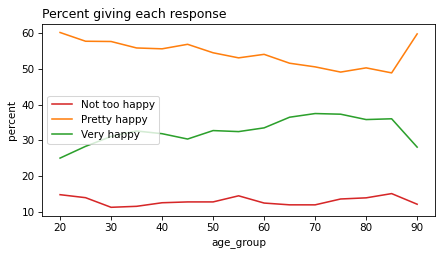

<IPython.core.display.Javascript object>

In [13]:
colors = ["C3", "C1", "C2"]
age_table.plot(color=colors)
decorate(ylabel="percent", title="Percent giving each response")

In [14]:
gss["cohort"] = gss["cohort"].replace(9999, np.nan)

<IPython.core.display.Javascript object>

In [15]:
gss["birth_group"] = round_into_bins(gss["cohort"], 5, low=1903) + 2
gss.groupby("birth_group")["cohort"].describe()

,count,mean,std,min,25%,50%,75%,max
birth_group,,,,,,,,
1905,1757.0,1901.289698,4.780700,1883.0,1899.0,1902.0,1905.0,1907.0
1910,1275.0,1910.114510,1.452892,1908.0,1909.0,1910.0,1911.5,1912.0
1915,1909.0,1915.102148,1.422174,1913.0,1914.0,1915.0,1916.0,1917.0
1920,2522.0,1920.087629,1.429506,1918.0,1919.0,1920.0,1921.0,1922.0
1925,3102.0,1925.071889,1.431998,1923.0,1924.0,1925.0,1926.0,1927.0
1930,3102.0,1930.059961,1.403783,1928.0,1929.0,1930.0,1931.0,1932.0
1935,3566.0,1935.065059,1.375492,1933.0,1934.0,1935.0,1936.0,1937.0
1940,4343.0,1940.103155,1.433124,1938.0,1939.0,1940.0,1941.0,1942.0
1945,5656.0,1945.124470,1.449801,1943.0,1944.0,1945.0,1946.0,1947.0


<IPython.core.display.Javascript object>

In [16]:
cohort_table = (
    pd.crosstab(gss["birth_group"], gss["y"], normalize="index").rename(
        columns=happy_map
    )
    * 100
)

<IPython.core.display.Javascript object>

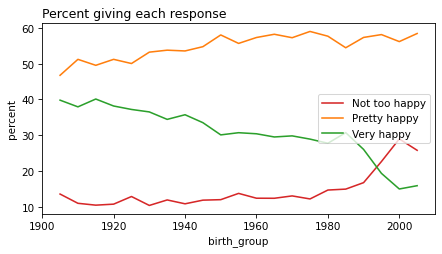

<IPython.core.display.Javascript object>

In [17]:
cohort_table.plot(color=colors)
decorate(ylabel="percent", title="Percent giving each response")

## Ordinal Regression

In [18]:
data_1 = gss.dropna(subset=["y", "age"])

<IPython.core.display.Javascript object>

In [19]:
data_1_sample = data_1.sample(5000)

<IPython.core.display.Javascript object>

In [20]:
y_1 = data_1_sample["y"].values
age_1 = data_1_sample["age"].values

# Center age
age_shift_1 = age_1.mean()
age_centered_1 = age_1 - age_shift_1

<IPython.core.display.Javascript object>

In [21]:
from scipy.special import logit

cutpoint_0 = logit(0.12)  # Cutpoint between "Not too happy" and "Pretty happy"
cutpoint_1 = logit(0.64)  # Cutpoint between "Pretty happy" and "Very happy"
cutpoints_1 = np.array([cutpoint_0, cutpoint_1])
print(f"cutpoints: {cutpoints_1}")

cutpoints: [-1.99243016  0.57536414]


<IPython.core.display.Javascript object>

### Simply syntax

In [22]:
with pm.Model(coords = {"obs_idx": np.arange(y_1.shape[0]), 
                        "cutpoint_id": ["Not / Pretty Happy", "Pretty / Very Happy"]}) as ordinal_model:
    # Data
    y_pt = pm.Data("y", y_1, dims=["obs_idx"])
    age_centered_pt = pm.Data("age_centered", age_centered_1, dims=["obs_idx"])

    # Priors for the cutpoints (thresholds) between categories
    cutpoints_pt = pm.Normal(
        "cutpoints",
        mu=cutpoints_1,
        sigma=0.5,
        transform=pm.distributions.transforms.ordered,
        dims=["cutpoint_id"],
    )

    # Age slope
    beta_age = pm.Normal("beta_age", 0, 0.1)

    # Compute cumulative logits
    eta = pm.Deterministic("eta", beta_age * age_centered_pt, dims=["obs_idx"])

    # Hide the details of the calculation
    y_obs = pm.OrderedLogistic(
        "y_obs", eta=eta, cutpoints=cutpoints_pt, compute_p=True, observed=y_pt, dims = ["obs_idx"]
    )

<IPython.core.display.Javascript object>

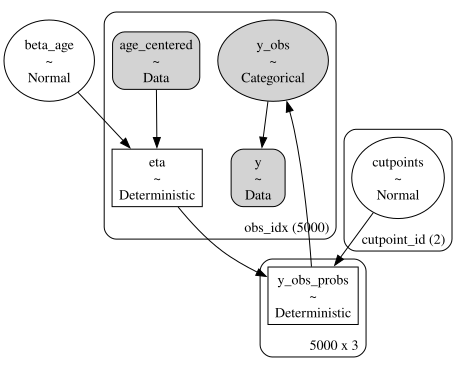

<IPython.core.display.Javascript object>

In [23]:
pm.model_to_graphviz(ordinal_model)

In [24]:
with ordinal_model:
    idata_ordinal = pm.sample(500, var_names = ["cutpoints", "beta_age"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta_age]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 7 seconds.


<IPython.core.display.Javascript object>

In [25]:
with pm.Model(coords = {"obs_idx": np.arange(y_1.shape[0]), 
                        "cutpoint_id": ["Not / Pretty Happy", "Pretty / Very Happy"],
                        "happy_id": ["Not too happy", "Pretty happy", "Very happy"]
                        }) as ordinal_model_explicit:
    # Data
    y_pt = pm.Data("y", y_1, dims=["obs_idx"])
    age_centered_pt = pm.Data("age_centered", age_centered_1, dims=["obs_idx"])

    # Priors for the cutpoints (thresholds) between categories
    cutpoints_pt = pm.Normal(
        "cutpoints",
        mu=cutpoints_1,
        sigma=0.5,
        shape=2,
        transform=pm.distributions.transforms.ordered,
        dims = ["cutpoint_id"]
    )

    # Age slope
    beta_age = pm.Normal("beta_age", 0, 0.1)

    # Linear predictor for each respondent (this is just age effect)
    eta = pm.Deterministic("eta", beta_age * age_centered_pt, dims = ["obs_idx"])

    # Compute cumulative logits for each observation and each cutpoint
    logits = pm.Deterministic("logits", cutpoints_pt - eta[:, None], dims = ["obs_idx", "cutpoint_id"])

    # Convert logits to cumulative probabilities
    cdf_0 = pm.math.sigmoid(logits[:, 0])  # P(y ≤ 0)
    cdf_1 = pm.math.sigmoid(logits[:, 1])  # P(y ≤ 1)

    # Convert cumulative probabilities to category probabilities
    p0 = cdf_0
    p1 = cdf_1 - cdf_0
    p2 = 1 - cdf_1

    # Stack into final probability matrix
    p = pm.Deterministic("p", pm.math.stack([p0, p1, p2], axis=1), dims = ["obs_idx", "happy_id"])

    # Likelihood using explicit p
    y_obs = pm.Categorical("y_obs", p=p, observed=y_pt, dims = ["obs_idx"])

<IPython.core.display.Javascript object>

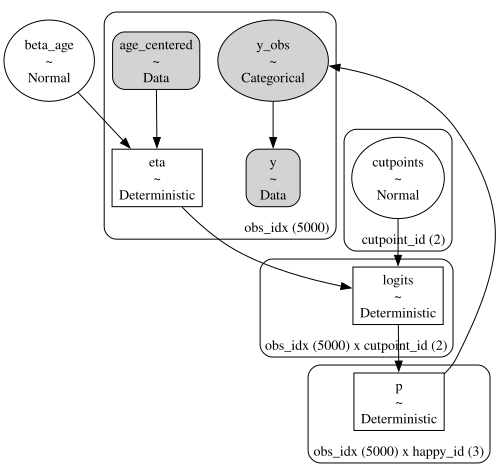

<IPython.core.display.Javascript object>

In [26]:
pm.model_to_graphviz(ordinal_model_explicit)

In [27]:
with ordinal_model_explicit:
    idata_ordinal_explicit = pm.sample(500, var_names = ["cutpoints", "beta_age"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta_age]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 5 seconds.


<IPython.core.display.Javascript object>

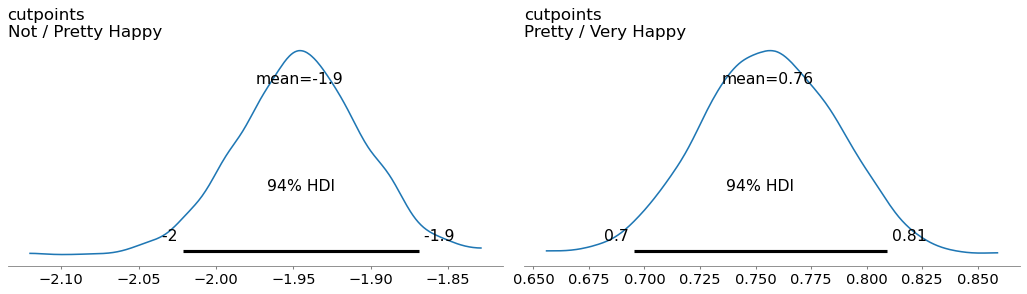

<IPython.core.display.Javascript object>

In [28]:
az.plot_posterior(idata_ordinal_explicit, var_names=["cutpoints"])
decorate()

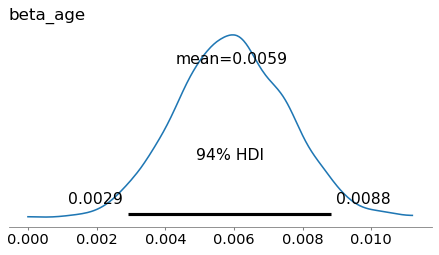

<IPython.core.display.Javascript object>

In [29]:
az.plot_posterior(idata_ordinal_explicit, var_names=["beta_age"])
decorate()

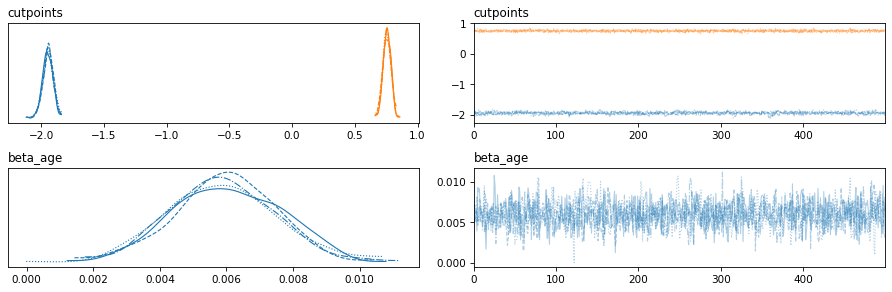

<IPython.core.display.Javascript object>

In [30]:
az.plot_trace(idata_ordinal_explicit)
decorate()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [31]:
az.summary(idata_ordinal_explicit)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[Not / Pretty Happy],-1.946,0.041,-2.021,-1.869,0.001,0.001,875.0,1054.0,1.01
cutpoints[Pretty / Very Happy],0.756,0.031,0.695,0.809,0.001,0.001,2408.0,1696.0,1.00
beta_age,0.006,0.002,0.003,0.009,0.000,0.000,1449.0,1337.0,1.00


<IPython.core.display.Javascript object>

### Interpreting the results

In [32]:
# Center the age range
age_range_pred_1 = np.arange(18, 95)
age_range_centered_pred_1 = age_range_pred_1 - age_shift_1
n_ages_pred_1 = len(age_range_pred_1)

<IPython.core.display.Javascript object>

In [33]:
with ordinal_model:
    pm.set_data({"age_centered": age_range_centered_pred_1},
                 coords={"obs_idx": np.arange(age_range_centered_pred_1.shape[0])}
                 )
    
    predictions_ordinal = pm.compute_deterministics(idata_ordinal.posterior, var_names = ["y_obs_probs"])

Output()

<IPython.core.display.Javascript object>

To make things a bit more obvious for plotting, we want to rename a few variables. Since we are using convenience functionality of PyMC via the `OrderedLogistic` distribution, we gave PyMC the right to choose some coordinate names, that we don't really like.

In [34]:
predictions_ordinal

<xarray.Dataset> Size: 4MB
Dimensions:            (chain: 4, draw: 500, y_obs_probs_dim_0: 77,
                        y_obs_probs_dim_1: 3)
Coordinates:
  * chain              (chain) int64 32B 0 1 2 3
  * draw               (draw) int64 4kB 0 1 2 3 4 5 ... 494 495 496 497 498 499
  * y_obs_probs_dim_0  (y_obs_probs_dim_0) int64 616B 0 1 2 3 4 ... 73 74 75 76
  * y_obs_probs_dim_1  (y_obs_probs_dim_1) int64 24B 0 1 2
Data variables:
    y_obs_probs        (chain, draw, y_obs_probs_dim_0, y_obs_probs_dim_1) float64 4MB ...
Attributes:
    created_at:                 2025-04-27T17:21:46.137803+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.21.1

<IPython.core.display.Javascript object>

Notice specifically the `y_obs_probs_dim_0` and `y_obs_probs_dim_1` variables. We have better names for those!

In [35]:
# Renaming for clarity
predictions_ordinal = predictions_ordinal.rename(
                                                {"y_obs_probs": "p", 
                                                "y_obs_probs_dim_0": "obs_idx", 
                                                "y_obs_probs_dim_1": "happy_id"})
predictions_ordinal = predictions_ordinal.assign_coords({"happy_id": ["Not too happy", "Pretty happy", "Very happy"]})

<IPython.core.display.Javascript object>

In [36]:
predictions_ordinal

<xarray.Dataset> Size: 4MB
Dimensions:   (chain: 4, draw: 500, obs_idx: 77, happy_id: 3)
Coordinates:
  * chain     (chain) int64 32B 0 1 2 3
  * draw      (draw) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499
  * obs_idx   (obs_idx) int64 616B 0 1 2 3 4 5 6 7 8 ... 69 70 71 72 73 74 75 76
  * happy_id  (happy_id) <U13 156B 'Not too happy' 'Pretty happy' 'Very happy'
Data variables:
    p         (chain, draw, obs_idx, happy_id) float64 4MB 0.1405 ... 0.4049
Attributes:
    created_at:                 2025-04-27T17:21:46.137803+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.21.1

<IPython.core.display.Javascript object>

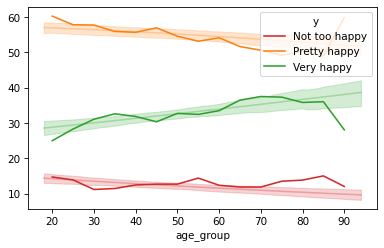

<IPython.core.display.Javascript object>

In [37]:
age_table.plot(color=colors)

for i, name in happy_map.items():
    predictions_tmp = predictions_ordinal.sel(happy_id = name)
    hdis_tmp = az.hdi(predictions_tmp, hdi_prob = 0.94)
    predictions_mean = predictions_tmp.mean(dim=["chain", "draw"])

    # plot mean
    plt.plot(age_range_pred_1,
             predictions_mean["p"].values * 100,
             color=colors[i],
             alpha = 0.3)
    
    # plot hdi
    plt.fill_between(age_range_pred_1,
                     hdis_tmp.sel(hdi="lower")["p"].values * 100,
                     hdis_tmp.sel(hdi="higher")["p"].values * 100,
                     color=colors[i],
                     alpha = 0.2)

## Adding a second predictor

In [38]:
data_2 = gss.dropna(subset=["y", "age", "cohort"])
data_2.shape

(66958, 63)

<IPython.core.display.Javascript object>

In [39]:
data_2_sample = data_2.sample(5000)

<IPython.core.display.Javascript object>

In [40]:
y_2 = data_2_sample["y"].values
age_2 = data_2_sample["age"].values
cohort_2 = data_2_sample["cohort"].values

# Center age
age_shift_2 = age_2.mean()
age_centered_2 = age_2 - age_shift_2

# Center cohort
cohort_shift_2 = cohort_2.mean()
cohort_centered_2 = cohort_2 - cohort_shift_2

<IPython.core.display.Javascript object>

In [41]:
# Repeating this for clarity
from scipy.special import logit

cutpoint_0 = logit(0.12)  # Cutpoint between "Not too happy" and "Pretty happy"
cutpoint_1 = logit(0.64)  # Cutpoint between "Pretty happy" and "Very happy"
cutpoints_2 = np.array([cutpoint_0, cutpoint_1])
print(f"cutpoints: {cutpoints_2}")

cutpoints: [-1.99243016  0.57536414]


<IPython.core.display.Javascript object>

In [42]:
with pm.Model(coords = {"obs_idx": np.arange(y_2.shape[0]), 
           "cutpoint_id": ["Not / Pretty Happy", "Pretty / Very Happy"],
           "happy_id": ["Not too happy", "Pretty happy", "Very happy"]
                        }) as ordinal_model2:
    # Data
    y_pt = pm.Data("y", y_2, dims = ["obs_idx"])
    age_centered_pt = pm.Data("age_centered", age_centered_2, dims = ["obs_idx"])
    cohort_centered_pt = pm.Data("cohort_centered", cohort_centered_2, dims = ["obs_idx"])

    # Priors for cutpoints (thresholds)
    cutpoints_pt = pm.Normal(
        "cutpoints",
        mu=cutpoints_2,
        sigma=0.5,
        transform=pm.distributions.transforms.ordered,
        dims = ["cutpoint_id"]
    )

    # Slopes for age and cohort
    beta_age = pm.Normal("beta_age", 0, 0.1)
    beta_cohort = pm.Normal("beta_cohort", 0, 0.1)

    # Linear predictor (age effect + cohort effect)
    eta = pm.Deterministic("eta", beta_age * age_centered_pt + beta_cohort * cohort_centered_pt, dims = ["obs_idx"])

    # Ordinal likelihood
    y_obs = pm.OrderedLogistic(
        "y_obs", eta=eta, cutpoints=cutpoints_pt, compute_p=True, observed=y_pt, dims = ["obs_idx"]
    )

<IPython.core.display.Javascript object>

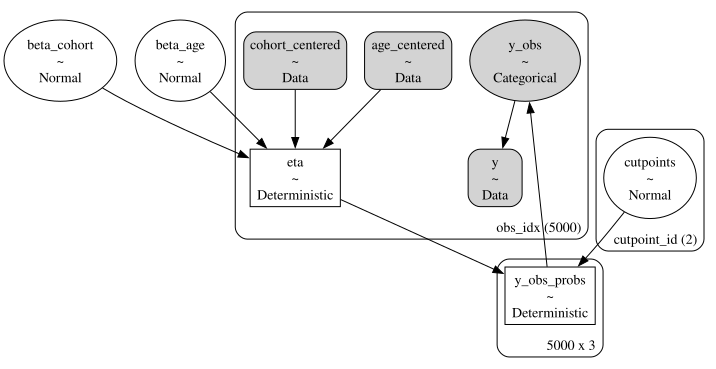

<IPython.core.display.Javascript object>

In [43]:
pm.model_to_graphviz(ordinal_model2)

In [44]:
with ordinal_model2:
    idata_ordinal2 = pm.sample(500, var_names = ["cutpoints", "beta_age", "beta_cohort"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [cutpoints, beta_age, beta_cohort]


Output()

Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 9 seconds.


<IPython.core.display.Javascript object>

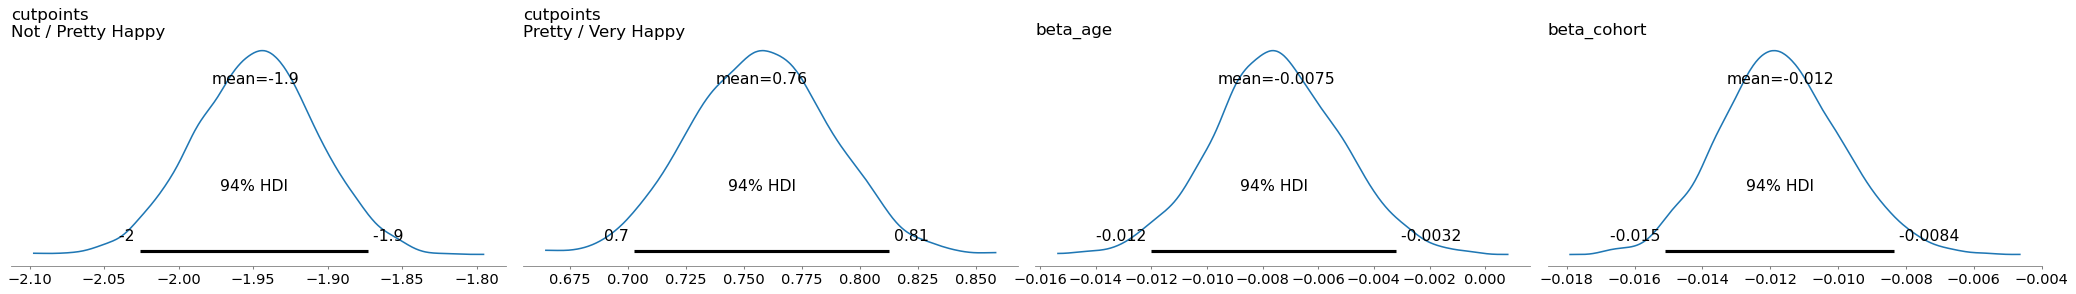

<IPython.core.display.Javascript object>

In [45]:
az.plot_posterior(idata_ordinal2)
decorate()

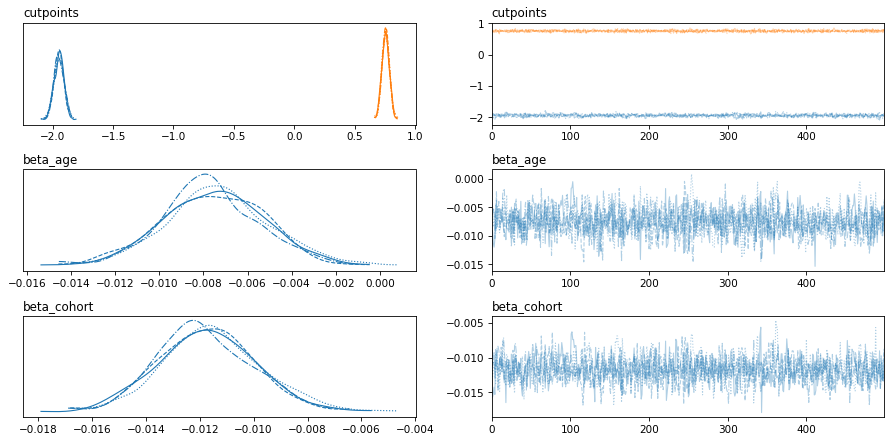

<IPython.core.display.Javascript object>

In [46]:
az.plot_trace(idata_ordinal2)
decorate()

In [47]:
az.summary(idata_ordinal2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
cutpoints[Not / Pretty Happy],-1.948,0.041,-2.026,-1.873,0.001,0.001,997.0,1226.0,1.0
cutpoints[Pretty / Very Happy],0.758,0.030,0.703,0.813,0.001,0.001,3055.0,1579.0,1.0
beta_age,-0.008,0.002,-0.012,-0.003,0.000,0.000,1372.0,1208.0,1.0
beta_cohort,-0.012,0.002,-0.015,-0.008,0.000,0.000,1203.0,950.0,1.0


<IPython.core.display.Javascript object>

### Plotting the results

#### Age range, fixed cohort

In [48]:
# Center the age range
age_range_pred_2 = np.arange(18, 95)
age_range_centered_pred_2 = age_range_pred_2 - age_shift_2

# Fixed cohort value
cohort_fixed_pred_2 = np.repeat(np.array([1960]), len(age_range_pred_2))
cohort_fixed_centered_pred_2 = cohort_fixed_pred_2 - cohort_shift_2

<IPython.core.display.Javascript object>

In [49]:
with ordinal_model2:
    pm.set_data({"cohort_centered": cohort_fixed_centered_pred_2,
                 "age_centered": age_range_centered_pred_2},
                 coords={"obs_idx": np.arange(age_range_centered_pred_2.shape[0])}
                 )
    
    predictions_ordinal2_age_range = pm.compute_deterministics(idata_ordinal2.posterior, var_names = ["y_obs_probs"])

Output()

<IPython.core.display.Javascript object>

In [50]:
# Cleanup idata for consistency with previous examples
predictions_ordinal2_age_range = predictions_ordinal2_age_range.rename(
                                                                {"y_obs_probs": "p", 
                                                                "y_obs_probs_dim_0": "obs_idx", 
                                                                "y_obs_probs_dim_1": "happy_id"})
predictions_ordinal2_age_range = predictions_ordinal2_age_range.assign_coords({"happy_id": ["Not too happy", "Pretty happy", "Very happy"]})

<IPython.core.display.Javascript object>

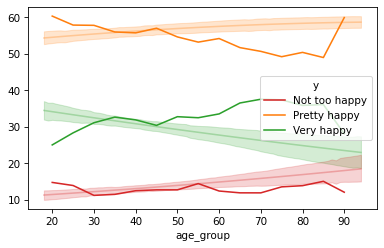

<IPython.core.display.Javascript object>

In [51]:
age_table.plot(color=colors)

for i, name in happy_map.items():
    predictions_tmp = predictions_ordinal2_age_range.sel(happy_id = name)
    hdis_tmp = az.hdi(predictions_tmp, hdi_prob = 0.94)
    predictions_mean = predictions_tmp.mean(dim=["chain", "draw"])

    # plot mean
    plt.plot(age_range_pred_2,
             predictions_mean["p"].values * 100,
             color=colors[i],
             alpha = 0.3)
    
    # plot hdi
    plt.fill_between(age_range_pred_2,
                     hdis_tmp.sel(hdi="lower")["p"].values * 100,
                     hdis_tmp.sel(hdi="higher")["p"].values * 100,
                     color=colors[i],
                     alpha = 0.2)

### Cohort range, fixed age

In [52]:
# Cohort range
cohort_range_pred_2 = np.arange(1905, 2010)
cohort_range_centered_pred_2 = cohort_range_pred_2 - cohort_shift_2

# Fixed age value
age_fixed_pred_2 = np.repeat(np.array([40]), len(cohort_range_pred_2))
age_fixed_centered_pred_2 = age_fixed_pred_2 - age_shift_2

<IPython.core.display.Javascript object>

In [53]:
with ordinal_model2:
    pm.set_data({"cohort_centered": cohort_range_centered_pred_2,
                 "age_centered": age_fixed_centered_pred_2},
                 coords={"obs_idx": np.arange(cohort_range_centered_pred_2.shape[0])}
                 )
    
    predictions_ordinal2_cohort_range = pm.compute_deterministics(idata_ordinal2.posterior, var_names = ["y_obs_probs"])

Output()

<IPython.core.display.Javascript object>

In [54]:
# Cleanup idata for consistency with previous examples
predictions_ordinal2_cohort_range = predictions_ordinal2_cohort_range.rename(
                            {"y_obs_probs": "p",
                             "y_obs_probs_dim_0": "obs_idx", 
                             "y_obs_probs_dim_1": "happy_id"})
predictions_ordinal2_cohort_range = predictions_ordinal2_cohort_range.assign_coords({"happy_id": ["Not too happy", "Pretty happy", "Very happy"]})

<IPython.core.display.Javascript object>

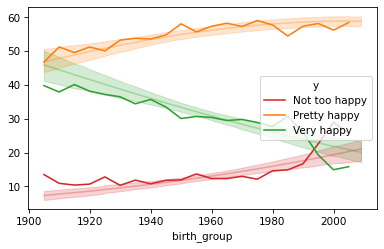

<IPython.core.display.Javascript object>

In [55]:
cohort_table.plot(color=colors)

for i, name in happy_map.items():
    predictions_tmp = predictions_ordinal2_cohort_range.sel(happy_id = name)
    hdis_tmp = az.hdi(predictions_tmp, hdi_prob = 0.94)
    predictions_mean = predictions_tmp.mean(dim=["chain", "draw"])

    # plot mean
    plt.plot(cohort_range_pred_2,
             predictions_mean["p"].values * 100,
             color=colors[i],
             alpha = 0.3)
    
    plt.fill_between(cohort_range_pred_2,
                     hdis_tmp.sel(hdi="lower")["p"].values * 100,
                     hdis_tmp.sel(hdi="higher")["p"].values * 100,
                     color=colors[i],
                     alpha = 0.2)